# The Effect of Schooling On Earnings - Instrumental Variables

This notebook focuses on applying instrumental variables (IV). The story of the first know use of instrumental variables may be familiar to you. In the late 19th Century John Snow used an IV design to prove that cholera was a waternborne disease (Cunnigham 2021). This notebook replicates the Angrist & Krueger (1991) study that used IVs to demonstrate the causal effect of extra schooling on earnings.

To understand how IVs help us identify causal effects and when to use them look at the DAG below. We want to understand the causal effect of schooling on earnings. However, both of these are confounded by ability which is unobserved. Therefore if we fit a linear regression of earnings on the data that we have, the coefficient estimate for schooling would be biased. This is where QOB comes in. QOB causes schooling (more on this below) and therefore is associated earnings and importantly it is not confounded by ability. This allows us to estimate the impact of schooling on earnings by estimating the impact of QOB on earnings and QOB on schooling and then taking the ratio. **Better explanation with the Math (Use Facure)**

3. This notebook 
    - Angrist & Krueger 1991 (How is this different to an RDD design) Replication
    - Summarise what the Authors did and the notebook 


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from dowhy import CausalModel
import statsmodels.api as sm
import numpy as np
import graphviz

c:\Users\caine\Documents\causal-inference\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


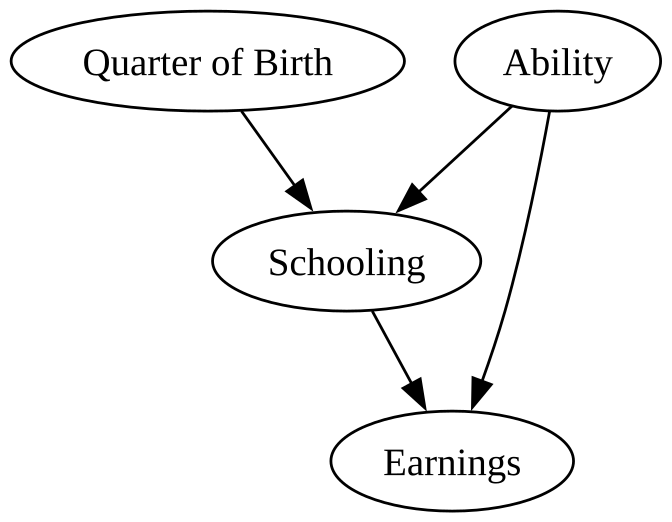

In [6]:
g = graphviz.Digraph()

g.attr(dpi='200')

g.edge('Schooling', 'Earnings')
g.edge('Ability', 'Schooling')
g.edge('Ability', 'Earnings')
g.edge('Quarter of Birth', 'Schooling')

g

## Assumptions required for IVs

If we think we have found an instrumental variable that can help us identify a causal effect then three assumptions must hold (Hernan & Robins 2020). Assume our instrumental variable is $Z% the treatment is $A$ and the response $Y$:

1. $Z$ is associated with $A$. This means changes to our instrument should be associated with changes in the treatment variable. Given the graph above you might have thought that this assumption should be that $Z$ causes $A%, however association is enough for Z to be an instrument (see Hernan & Robins 2020; p.210). 

2. $Z$ does not affect $Y$ except through its affect on $A$. If this assumption holds we can be sure that changes in $Y$ associated with changes $Z$ are due to the intermediate changes in $A$ - after all its the causal effect of $A$ on $Y$ that we are trying to calculate. 

3. $Z$ and $Y$ do not share causes - there is no confounder of Z and Y. If there was confounding it would mean that some of changes in $Z$ and $Y$ were actually due to the confounder and not $Z's$ impact on $Y$ through $A$

These assumptions are only necessary and not sufficient (Hernan & Robins 2020). For the IV to identify the causal effect a fourth assumtpion must also hold

4. Homogeneity. The most extreme homogeneity conidition is the constant effect of the treatment on the response - that is every unit responds exactly the same to treatment. This is usually considered to be unrealistic. Because of this there are more relaxed versions of this assumption and each has a slightly different intepretation (Hernan & Robins 2020: p.214-217).

There is an alternative to the homogeneity assumption and this is discussed in the "LATE - Monotonicity Assumption" section below

## Load Data

This is the original dataset from the Angrist & Krueger paper (1991). THe dataset contains:

- log wage
- years of school 
- year of birth
- quarter of birth
- state of birth

Angrist & Krueger (1991) indeitified *quarter of birth* as the instrumental variable. Their rationale was US law required a child to stay in school up until they were 16. Once they turned 16 they could legally drop out. Furthermore, school districts required that a child had turned 6 by the 1st Jan to be eligible for the following shcool year. This combination of complusory schooling and school entry requirements meant children born in the later months of the year would be required to complete more schooling then those born in the earlier months of the year. Furthermore, there is no reason to believe that month of birth can have any affect on earnings except through the affect it has on the amount of schooling a person receives. 

The argument makes sense. Lets see if the data supports it.

In [10]:
df = pd.read_stata('ak91.dta')
df.head()

,lnw,s,yob,qob,sob
0,5.790019,12.0,30.0,1.0,45.0
1,5.952494,11.0,30.0,1.0,45.0
2,5.315949,12.0,30.0,1.0,45.0
3,5.595926,12.0,30.0,1.0,45.0
4,6.068915,12.0,30.0,1.0,37.0


*what does the data show*

In [23]:
mean_school_earnings_by_yob_qob = df.groupby(['yob', 'qob'], as_index=False)[['s', 'lnw']].mean()
mean_school_earnings_by_yob_qob['tob'] = (mean_school_earnings_by_yob_qob['yob']) + (mean_school_earnings_by_yob_qob['qob'] / 4)

Text(0.5, 1.0, 'Average Years of Schooling by Time of Birth')

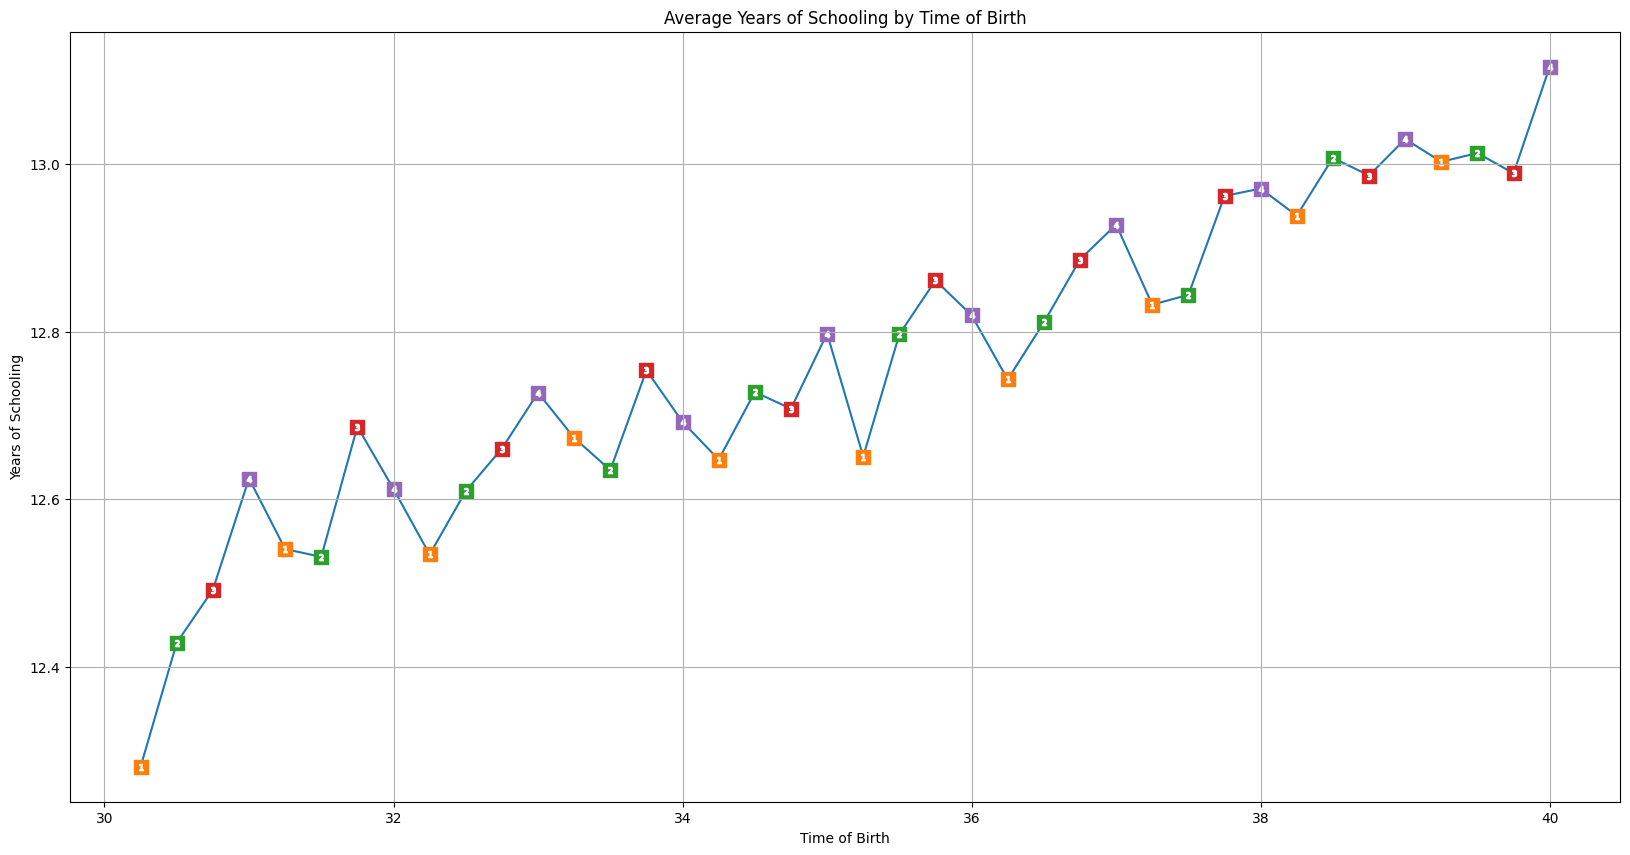

In [35]:
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(
    mean_school_earnings_by_yob_qob['tob'],
    mean_school_earnings_by_yob_qob['s'],
    zorder=-1,
)

for q in range(1, 5):
    tob = mean_school_earnings_by_yob_qob[mean_school_earnings_by_yob_qob['qob'] == q]['tob']
    yos = mean_school_earnings_by_yob_qob[mean_school_earnings_by_yob_qob['qob'] == q]['s']
    ax.scatter(tob, yos, marker='s', s=100, c=f"C{q}" )
    ax.scatter(tob, yos, marker=f"${q}$", s=20, c='white')

ax.set_xlabel('Time of Birth')
ax.set_ylabel('Years of Schooling')
ax.grid()
ax.set_title('Average Years of Schooling by Time of Birth')



Text(0.5, 1.0, 'Average Log Earnings by Time of Birth')

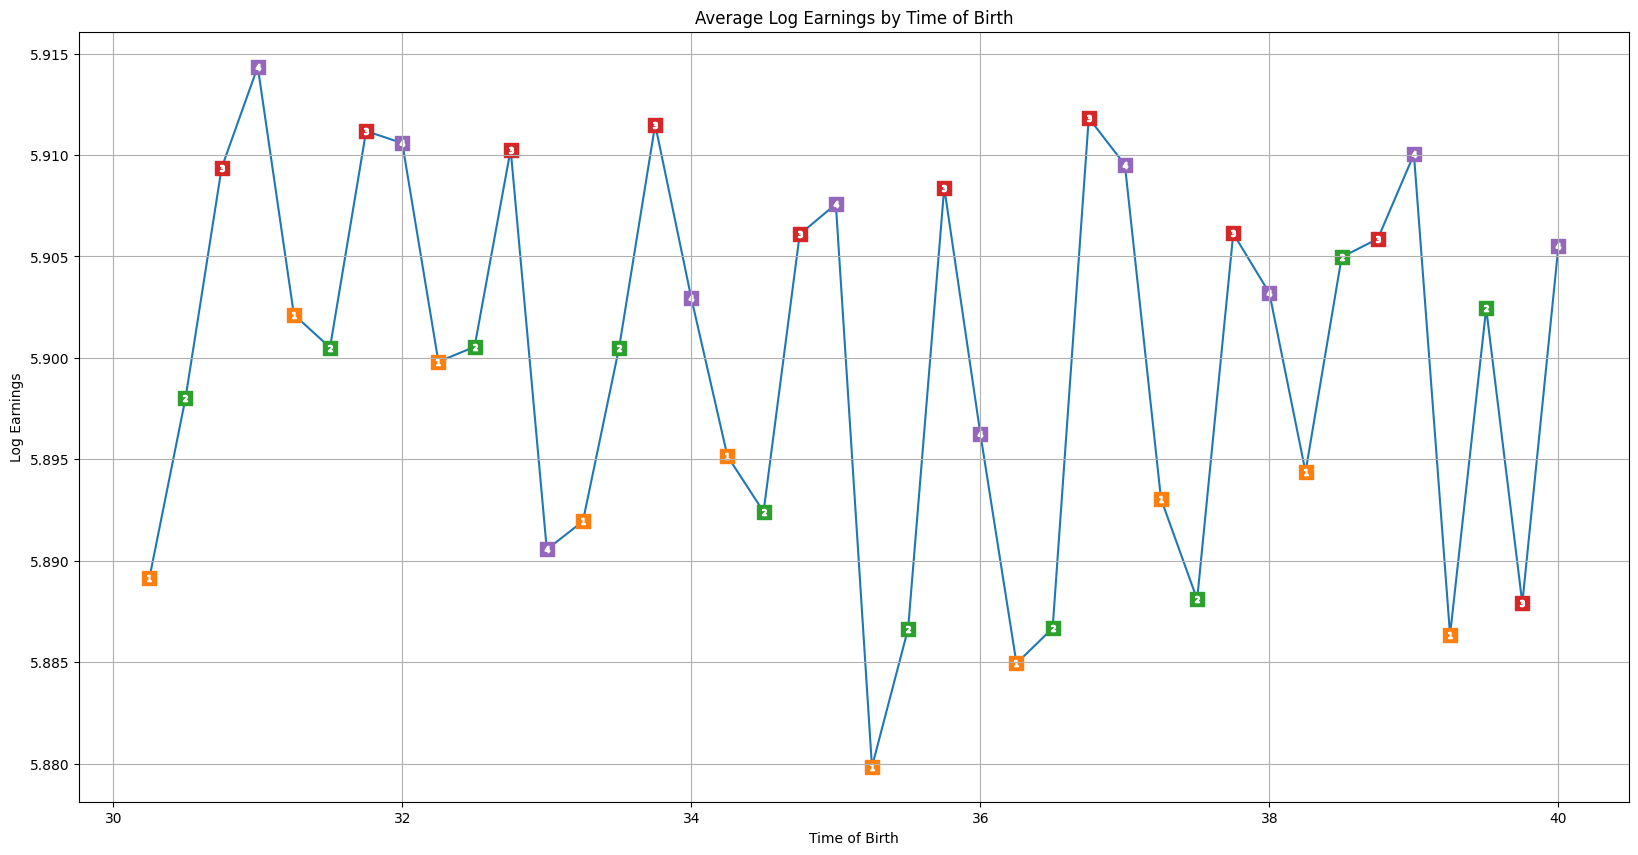

In [41]:
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(
    mean_school_earnings_by_yob_qob['tob'],
    mean_school_earnings_by_yob_qob['lnw'],
    zorder=-1,
)

for q in range(1, 5):
    tob = mean_school_earnings_by_yob_qob[mean_school_earnings_by_yob_qob['qob'] == q]['tob']
    lnw = mean_school_earnings_by_yob_qob[mean_school_earnings_by_yob_qob['qob'] == q]['lnw']
    ax.scatter(tob, lnw, marker='s', s=100, c=f"C{q}" )
    ax.scatter(tob, lnw, marker=f"${q}$", s=20, c='white')

ax.set_xlabel('Time of Birth')
ax.set_ylabel('Log Earnings')
ax.grid()
ax.set_title('Average Log Earnings by Time of Birth')


Text(0.5, 1.0, 'Log Earnings by Years of Schooling')

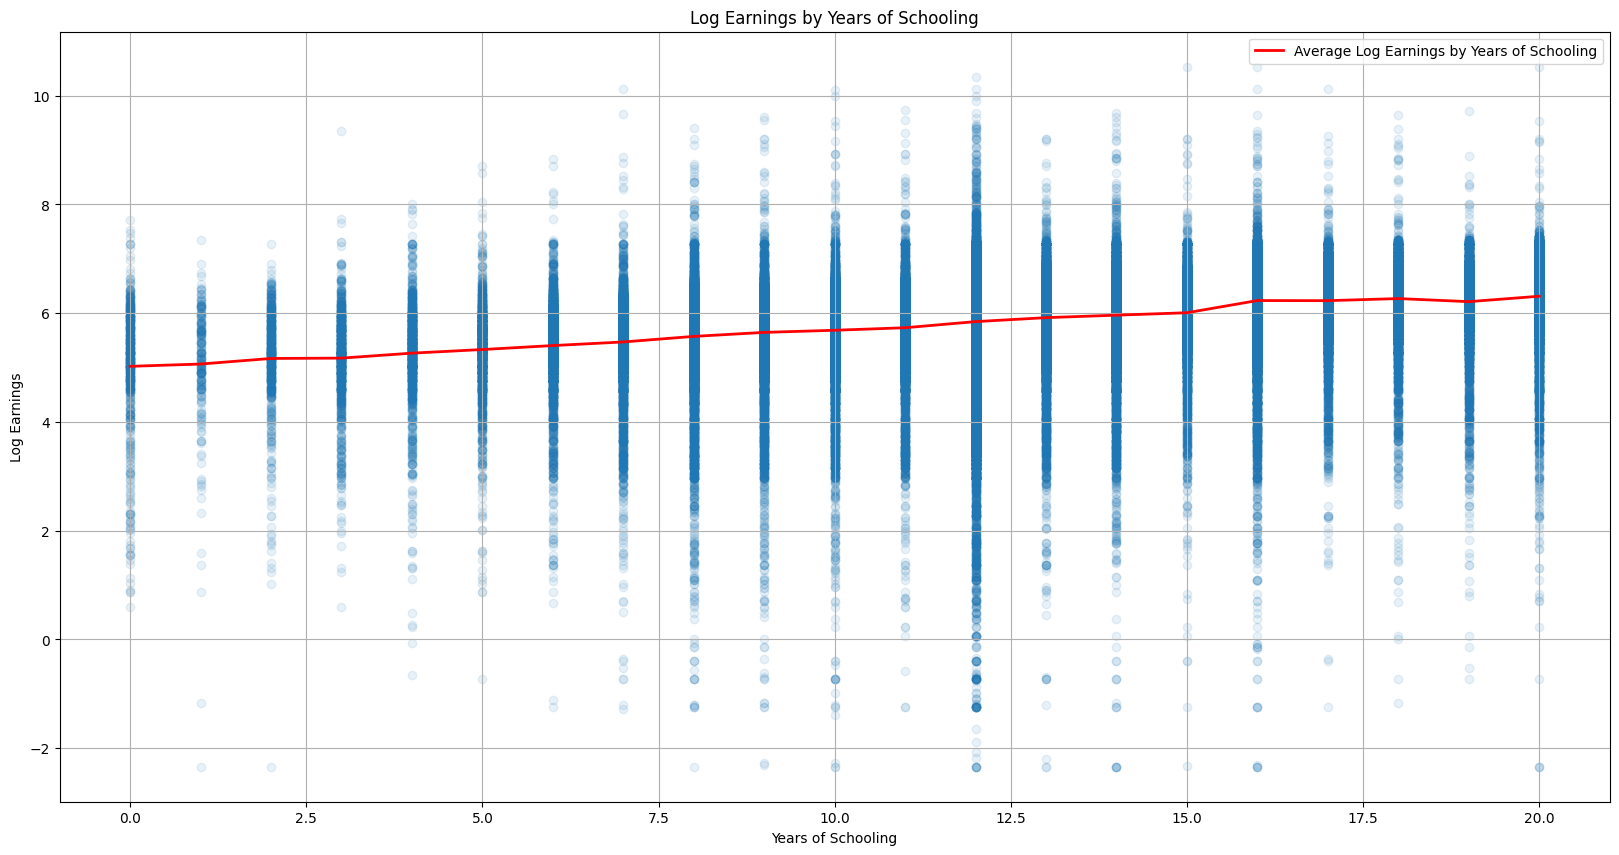

In [49]:
fig, ax = plt.subplots(figsize=(20, 10))

mean_earnings_by_schooling = df.groupby('s', as_index=False)['lnw'].mean()
ax.scatter(
    df['s'],
    df['lnw'],
    alpha=0.1,
)
ax.plot(
    mean_earnings_by_schooling['s'],
    mean_earnings_by_schooling['lnw'],
    color='red',
    linewidth=2,
    label='Average Log Earnings by Years of Schooling',
)

ax.legend()
ax.set_xlabel('Years of Schooling')
ax.set_ylabel('Log Earnings')
ax.grid()
ax.set_title('Log Earnings by Years of Schooling')

## OLS vs 2SOLS

- Why do we need two stage OLS (we need to understand this) - the OLS is biased why? (FACURE)

- Compare the estimates (Ability as a confounder between school and earnings)

In [ ]:
# Estimates and table displayed

## Diagnostics

- Fstatistic (weak or strong instrument)

## LATE - Monotonicity Assumption

- ... (need to hink about this) Hernan and Robins very good again

## Estimation using DoWHY

Here we use DoWhy - why?

# Bibliography

Cunningham, Scott. 2021. Causal Inference: The Mixtape. New Haven: Yale University Press.

Hernan & Robins 2020

Angrist & Krueger 1991